<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Exploratory_Data_Analysis_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports & settings
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import re, os, warnings
from collections import Counter
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# Global plot style
plt.rcParams.update({
    "figure.dpi"      : 140,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "font.family"     : "DejaVu Sans",
    "axes.titlesize"  : 11,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 9,
    "xtick.labelsize" : 8,
    "ytick.labelsize" : 8,
    "legend.fontsize" : 8,
})

# Consistent colour palette
C_BLUE   = "#5B9BD5"
C_RED    = "#E07B7B"
C_GREEN  = "#5BAD8E"
C_ORANGE = "#F5A623"
C_PURPLE = "#9467BD"
C_GREY   = "#7F7F7F"

DOMAIN_COLORS = {
    "Finance":            "#1F77B4",
    "IoT & Smart Systems":"#FF7F0E",
    "Ecommerce":          "#2CA02C",
    "Healthcare":         "#D62728",
    "Education":          "#9467BD",
    "Social Media":       "#8C564B",
    "Logistics":          "#E377C2",
    "HR & Recruitment":   "#7F7F7F",
    "Travel & Hospitality":"#BCBD22",
    "Real Estate":        "#17BECF",
}

DOMAIN_ORDER = [
    "Finance","IoT & Smart Systems","Ecommerce","Healthcare",
    "Education","Social Media","Logistics",
    "HR & Recruitment","Travel & Hospitality","Real Estate",
]

print("✓ Libraries imported")

✓ Libraries imported


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load dataset
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload: github_projects_cleaned.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print(f"\n✓ Loaded {len(df):,} rows × {len(df.columns)} columns")

# Apply same rare-class grouping as preprocessing
RARE_FE = {"Svelte"}
RARE_BE = {"Express","FastAPI","PHP","Firebase"}
RARE_DB = {"Elasticsearch","DynamoDB","Cassandra","Oracle","Firestore"}
df["Frontend_Tech"] = df["Frontend_Tech"].apply(lambda x:"Other" if x in RARE_FE else x)
df["Backend_Tech"]  = df["Backend_Tech"].apply(lambda x:"Other" if x in RARE_BE else x)
df["Database"]      = df["Database"].apply(lambda x:"Other" if x in RARE_DB else x)
df["Primary_Language"] = df["Primary_Language"].fillna("Unknown")

print("✓ Rare classes grouped into 'Other' (consistent with preprocessing)")

Upload: github_projects_cleaned.xlsx


Saving github_projects_cleaned.xlsx to github_projects_cleaned.xlsx

✓ Loaded 4,437 rows × 19 columns
✓ Rare classes grouped into 'Other' (consistent with preprocessing)


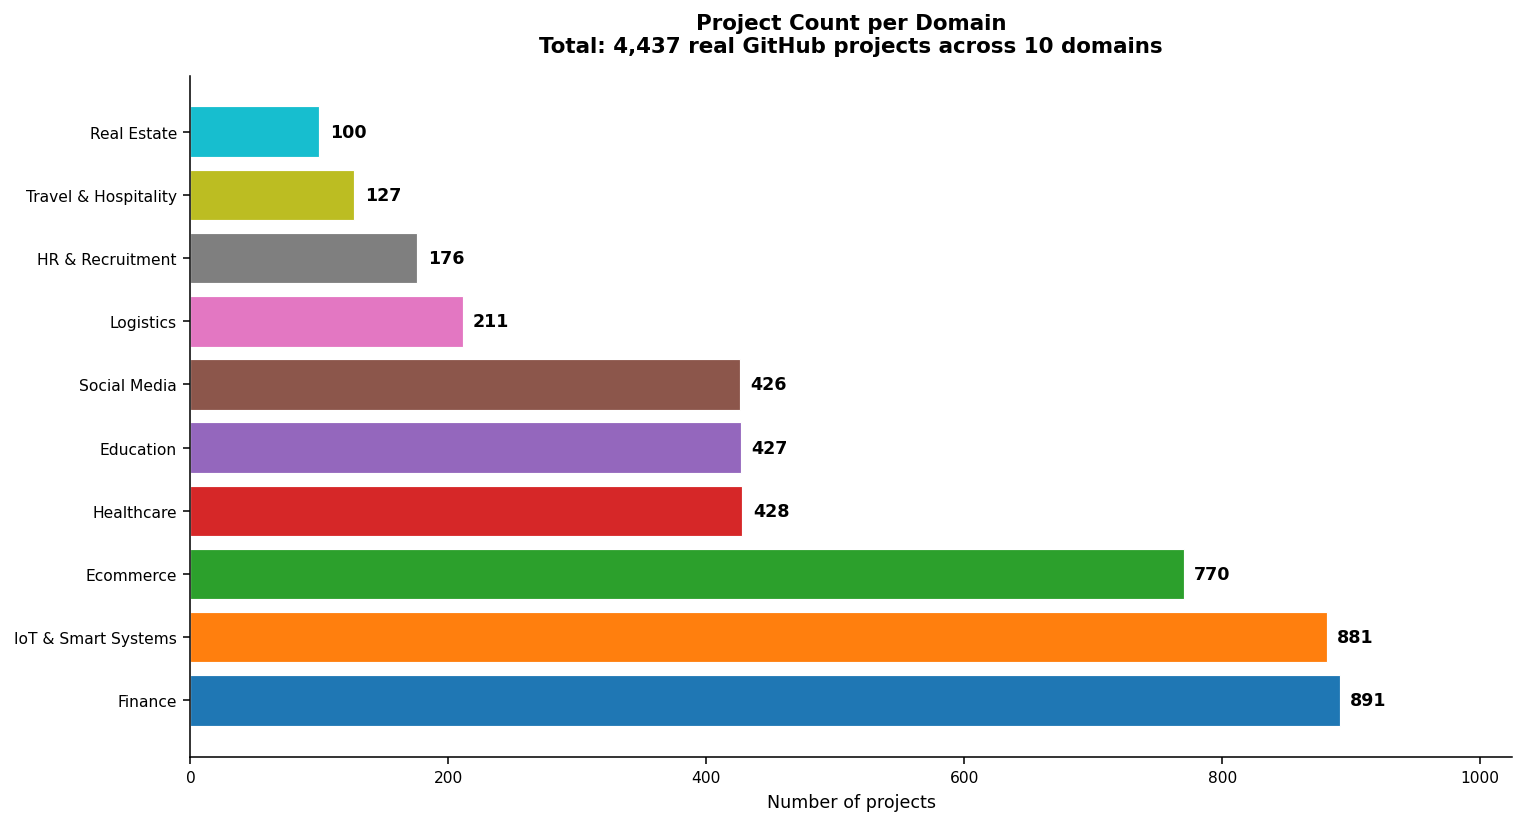

✓ Chart 1 saved → eda_01_domain_counts.png

  Domain with most projects  : Finance (891)
  Domain with fewest projects: Real Estate (100)
  Imbalance ratio            : 8.9×


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ CHART 1: Dataset overview — domain distribution
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

counts = df["Domain"].value_counts().reindex(DOMAIN_ORDER)
colors = [DOMAIN_COLORS[d] for d in DOMAIN_ORDER]
bars   = ax.barh(DOMAIN_ORDER, counts.values,
                 color=colors, edgecolor="white", linewidth=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Number of projects")
ax.set_title(
    "Project Count per Domain\n"
    f"Total: {len(df):,} real GitHub projects across 10 domains",
    pad=12)
ax.set_xlim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("eda_01_domain_counts.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → eda_01_domain_counts.png")
print(f"\n  Domain with most projects  : Finance ({counts['Finance']:,})")
print(f"  Domain with fewest projects: Real Estate ({counts['Real Estate']:,})")
print(f"  Imbalance ratio            : {counts.max()/counts.min():.1f}×")

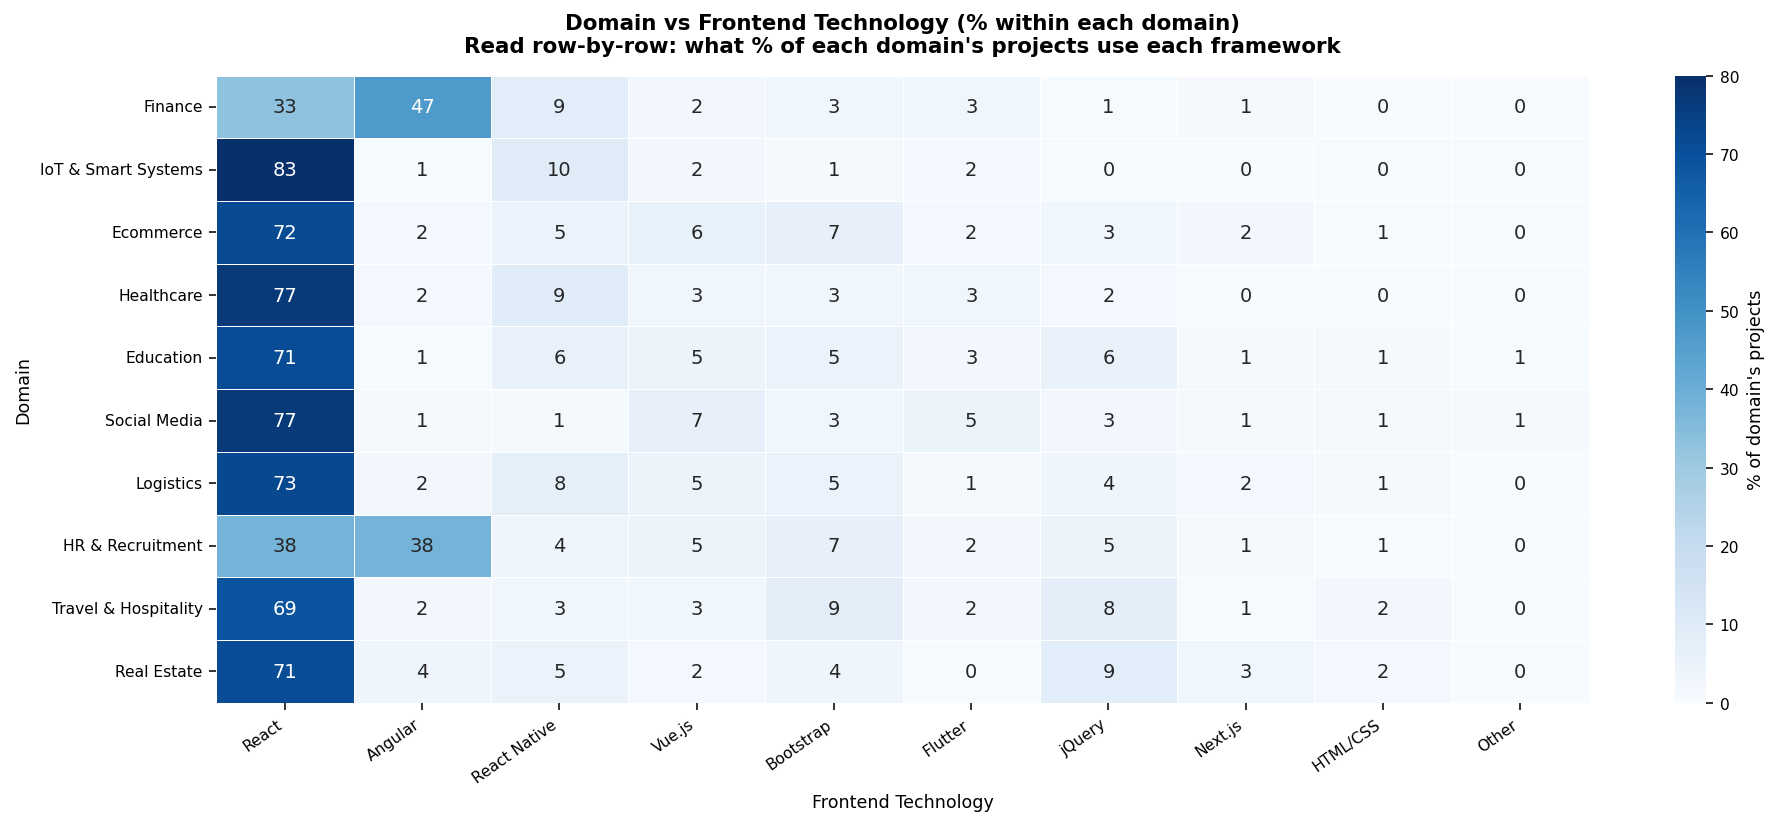

✓ Chart 2 saved → eda_02_domain_vs_frontend.png

  Key finding — Frontend by domain:
    Finance                    → Angular        (47%)
    IoT & Smart Systems        → React          (83%)
    Ecommerce                  → React          (72%)
    Healthcare                 → React          (77%)
    Education                  → React          (71%)
    Social Media               → React          (77%)
    Logistics                  → React          (73%)
    HR & Recruitment           → React          (38%)
    Travel & Hospitality       → React          (69%)
    Real Estate                → React          (71%)


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ CHART 2: Domain vs Frontend Tech (heatmap %)
# ══════════════════════════════════════════════════════════════
# Directly answers RQ1: domain is the key predictor of frontend
fe_ct  = pd.crosstab(df["Domain"], df["Frontend_Tech"])
fe_pct = fe_ct.div(fe_ct.sum(axis=1), axis=0) * 100

# Order columns by total usage
col_order = fe_ct.sum().sort_values(ascending=False).index.tolist()
fe_pct    = fe_pct.reindex(DOMAIN_ORDER)[col_order]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    fe_pct, annot=True, fmt=".0f",
    cmap="Blues", linewidths=0.4, linecolor="white",
    cbar_kws={"label":"% of domain's projects"},
    ax=ax, vmin=0, vmax=80
)
ax.set_title(
    "Domain vs Frontend Technology (% within each domain)\n"
    "Read row-by-row: what % of each domain's projects use each framework",
    pad=12)
ax.set_xlabel("Frontend Technology")
ax.set_ylabel("Domain")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_02_domain_vs_frontend.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → eda_02_domain_vs_frontend.png")

print("\n  Key finding — Frontend by domain:")
for domain in DOMAIN_ORDER:
    row = fe_pct.loc[domain]
    top = row.idxmax(); pct = row.max()
    print(f"    {domain:<26} → {top:<14} ({pct:.0f}%)")

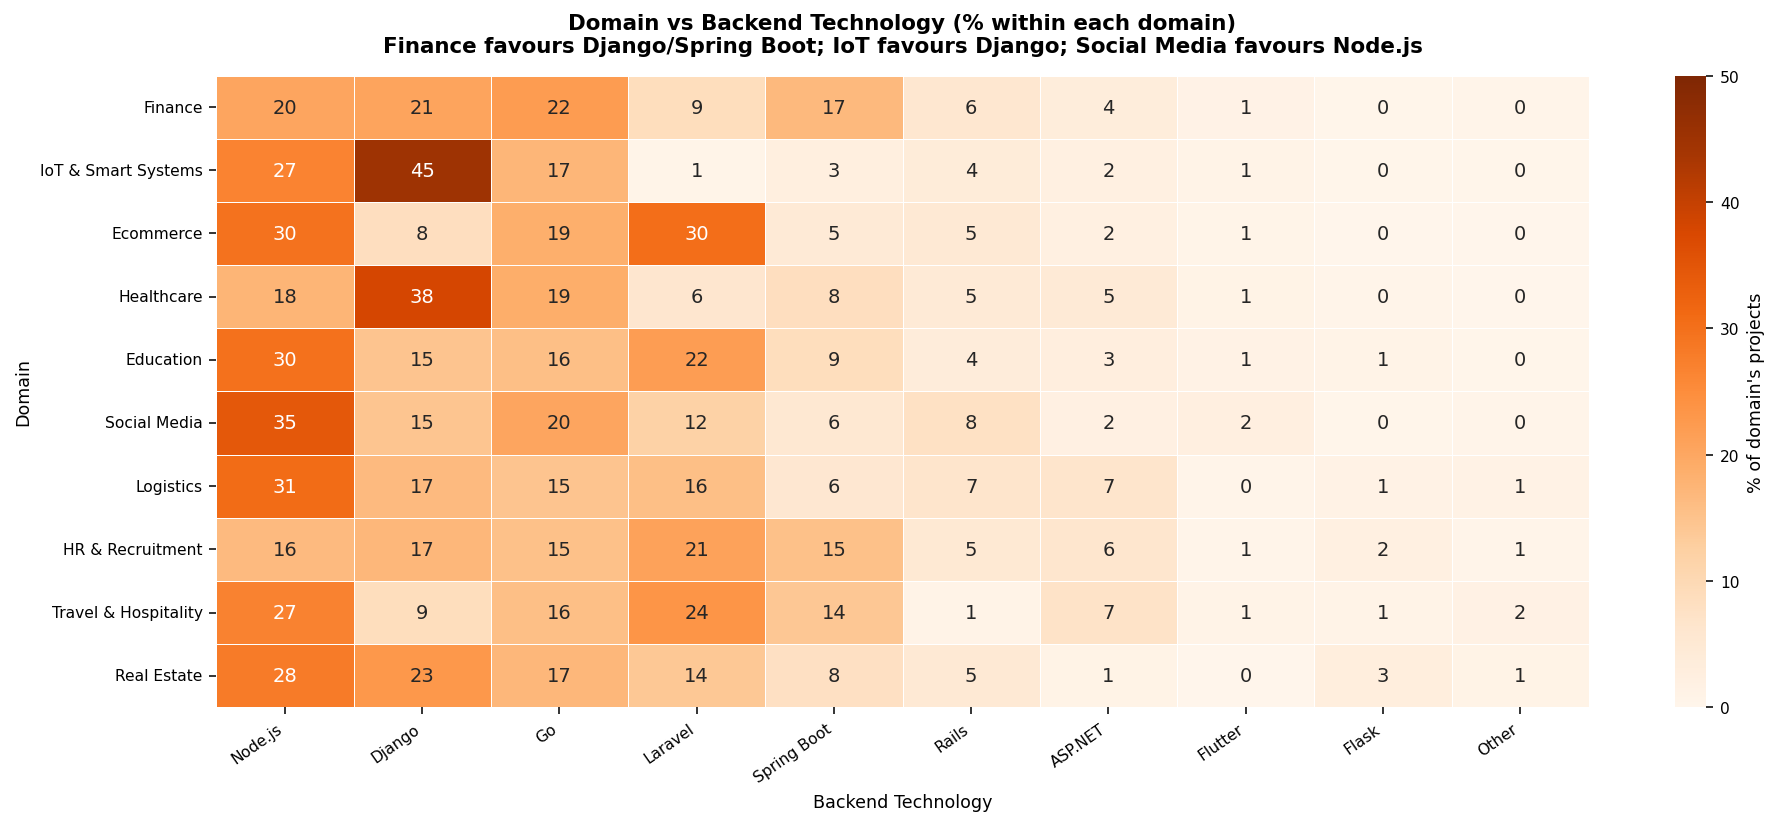

✓ Chart 3 saved → eda_03_domain_vs_backend.png

  Key finding — Backend by domain:
    Finance                    → Go             (22%)
    IoT & Smart Systems        → Django         (45%)
    Ecommerce                  → Laravel        (30%)
    Healthcare                 → Django         (38%)
    Education                  → Node.js        (30%)
    Social Media               → Node.js        (35%)
    Logistics                  → Node.js        (31%)
    HR & Recruitment           → Laravel        (21%)
    Travel & Hospitality       → Node.js        (27%)
    Real Estate                → Node.js        (28%)


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ CHART 3: Domain vs Backend Tech (heatmap %)
# ══════════════════════════════════════════════════════════════
be_ct  = pd.crosstab(df["Domain"], df["Backend_Tech"])
be_pct = be_ct.div(be_ct.sum(axis=1), axis=0) * 100
col_order_be = be_ct.sum().sort_values(ascending=False).index.tolist()
be_pct = be_pct.reindex(DOMAIN_ORDER)[col_order_be]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    be_pct, annot=True, fmt=".0f",
    cmap="Oranges", linewidths=0.4, linecolor="white",
    cbar_kws={"label":"% of domain's projects"},
    ax=ax, vmin=0, vmax=50
)
ax.set_title(
    "Domain vs Backend Technology (% within each domain)\n"
    "Finance favours Django/Spring Boot; IoT favours Django; Social Media favours Node.js",
    pad=12)
ax.set_xlabel("Backend Technology")
ax.set_ylabel("Domain")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_03_domain_vs_backend.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → eda_03_domain_vs_backend.png")

print("\n  Key finding — Backend by domain:")
for domain in DOMAIN_ORDER:
    row = be_pct.loc[domain]
    top = row.idxmax(); pct = row.max()
    print(f"    {domain:<26} → {top:<14} ({pct:.0f}%)")

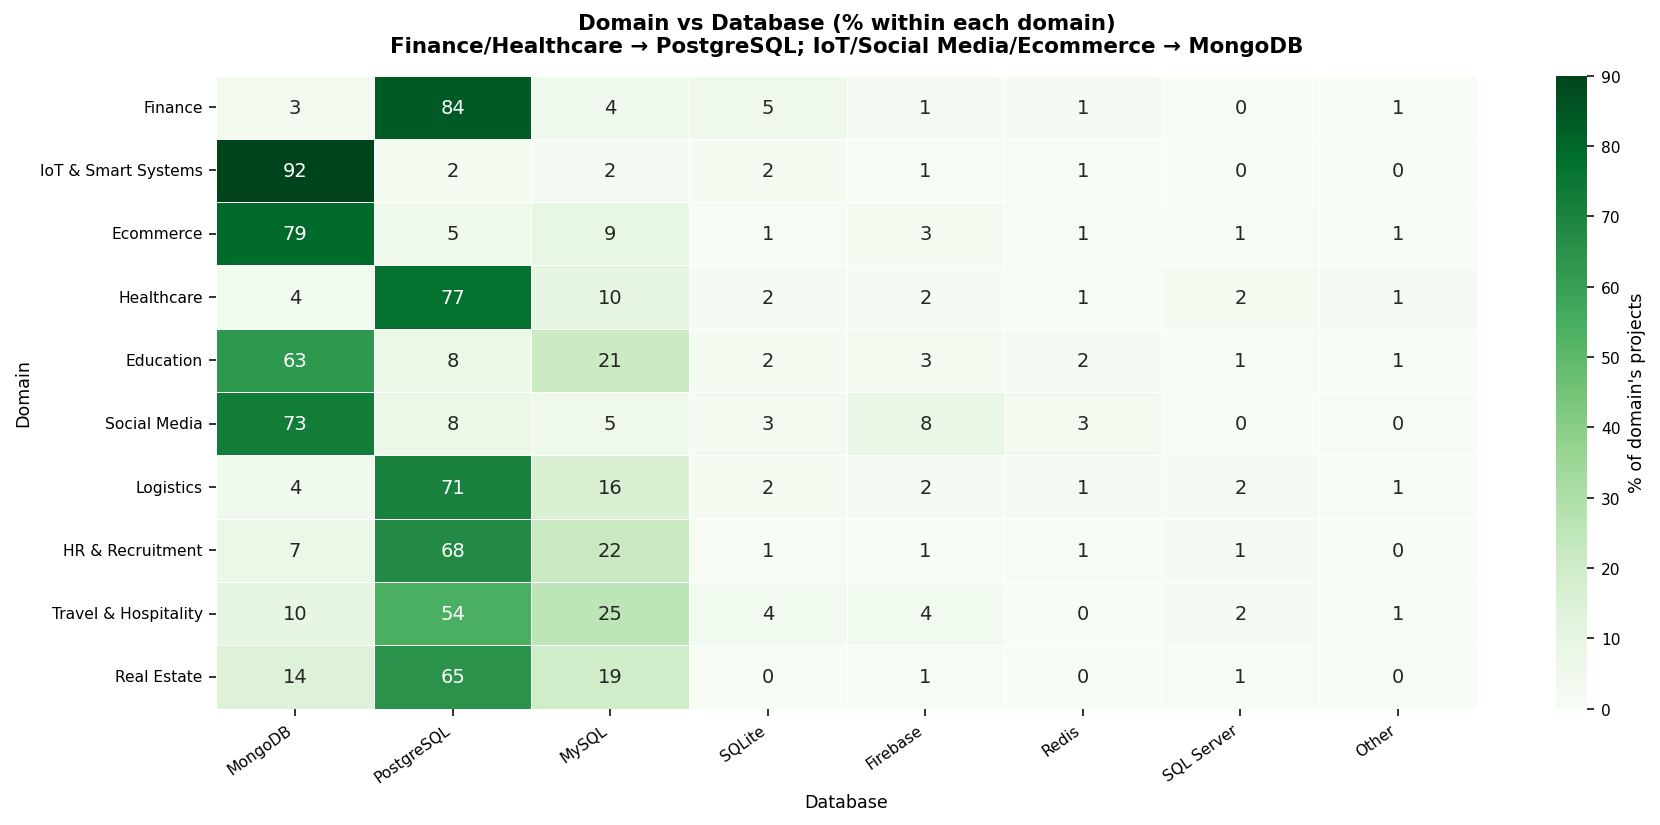

✓ Chart 4 saved → eda_04_domain_vs_database.png

  Key finding — Database by domain:
    Finance                    → PostgreSQL     (84%)
    IoT & Smart Systems        → MongoDB        (92%)
    Ecommerce                  → MongoDB        (79%)
    Healthcare                 → PostgreSQL     (77%)
    Education                  → MongoDB        (63%)
    Social Media               → MongoDB        (73%)
    Logistics                  → PostgreSQL     (71%)
    HR & Recruitment           → PostgreSQL     (68%)
    Travel & Hospitality       → PostgreSQL     (54%)
    Real Estate                → PostgreSQL     (65%)


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ CHART 4: Domain vs Database (heatmap %)
# ══════════════════════════════════════════════════════════════
db_ct  = pd.crosstab(df["Domain"], df["Database"])
db_pct = db_ct.div(db_ct.sum(axis=1), axis=0) * 100
col_order_db = db_ct.sum().sort_values(ascending=False).index.tolist()
db_pct = db_pct.reindex(DOMAIN_ORDER)[col_order_db]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    db_pct, annot=True, fmt=".0f",
    cmap="Greens", linewidths=0.4, linecolor="white",
    cbar_kws={"label":"% of domain's projects"},
    ax=ax, vmin=0, vmax=90
)
ax.set_title(
    "Domain vs Database (% within each domain)\n"
    "Finance/Healthcare → PostgreSQL; IoT/Social Media/Ecommerce → MongoDB",
    pad=12)
ax.set_xlabel("Database")
ax.set_ylabel("Domain")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_04_domain_vs_database.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → eda_04_domain_vs_database.png")

print("\n  Key finding — Database by domain:")
for domain in DOMAIN_ORDER:
    row = db_pct.loc[domain]
    top = row.idxmax(); pct = row.max()
    print(f"    {domain:<26} → {top:<14} ({pct:.0f}%)")

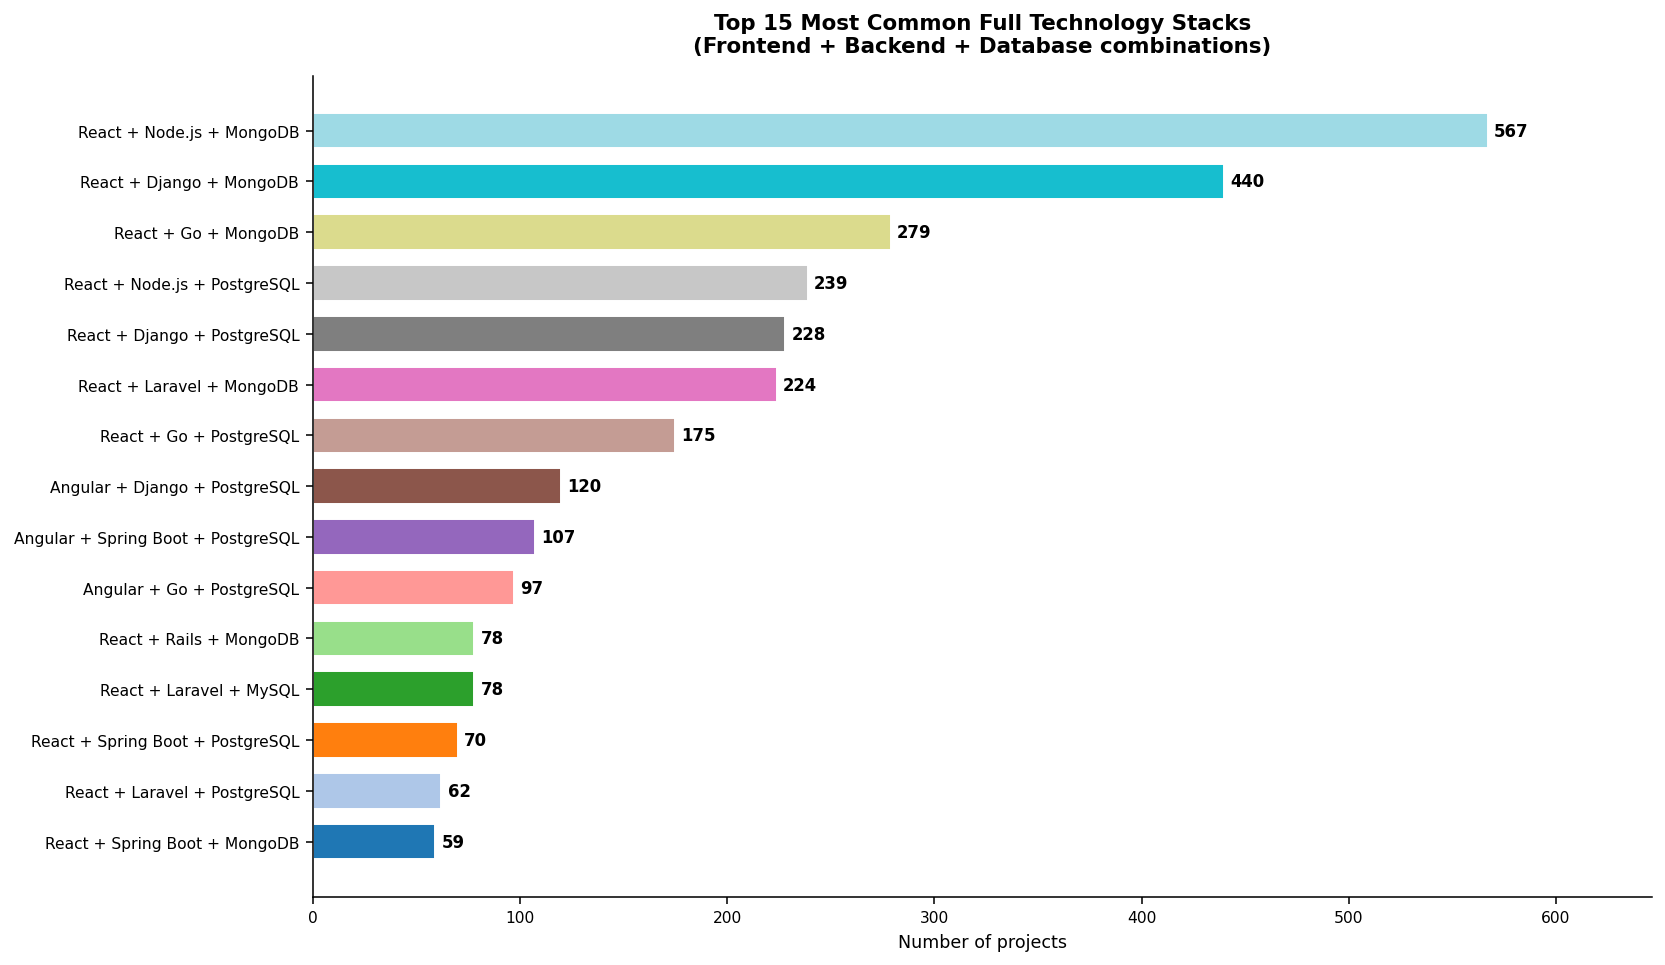

✓ Chart 5 saved → eda_05_top_stacks.png

  #1 stack: React + Node.js + MongoDB (567 projects, 12.8%)
  Top 5 stacks cover 39.5% of all projects


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ CHART 5: Top 15 complete tech stacks
# ══════════════════════════════════════════════════════════════
stacks = (
    df.groupby(["Frontend_Tech","Backend_Tech","Database"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
      .head(15)
)
stacks["Stack"] = (stacks["Frontend_Tech"] + " + " +
                   stacks["Backend_Tech"]   + " + " +
                   stacks["Database"])

fig, ax = plt.subplots(figsize=(12, 7))
colors_s = plt.cm.tab20(np.linspace(0, 1, 15))
bars = ax.barh(stacks["Stack"][::-1], stacks["count"][::-1],
               color=colors_s, edgecolor="white", height=0.7)
for bar, val in zip(bars, stacks["count"][::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8.5, fontweight="bold")

ax.set_xlabel("Number of projects")
ax.set_title(
    "Top 15 Most Common Full Technology Stacks\n"
    "(Frontend + Backend + Database combinations)",
    pad=12)
ax.set_xlim(0, stacks["count"].max() * 1.14)
plt.tight_layout()
plt.savefig("eda_05_top_stacks.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → eda_05_top_stacks.png")
print(f"\n  #1 stack: {stacks.iloc[0]['Stack']} "
      f"({stacks.iloc[0]['count']} projects, "
      f"{stacks.iloc[0]['count']/len(df)*100:.1f}%)")
print(f"  Top 5 stacks cover "
      f"{stacks.head(5)['count'].sum()/len(df)*100:.1f}% of all projects")

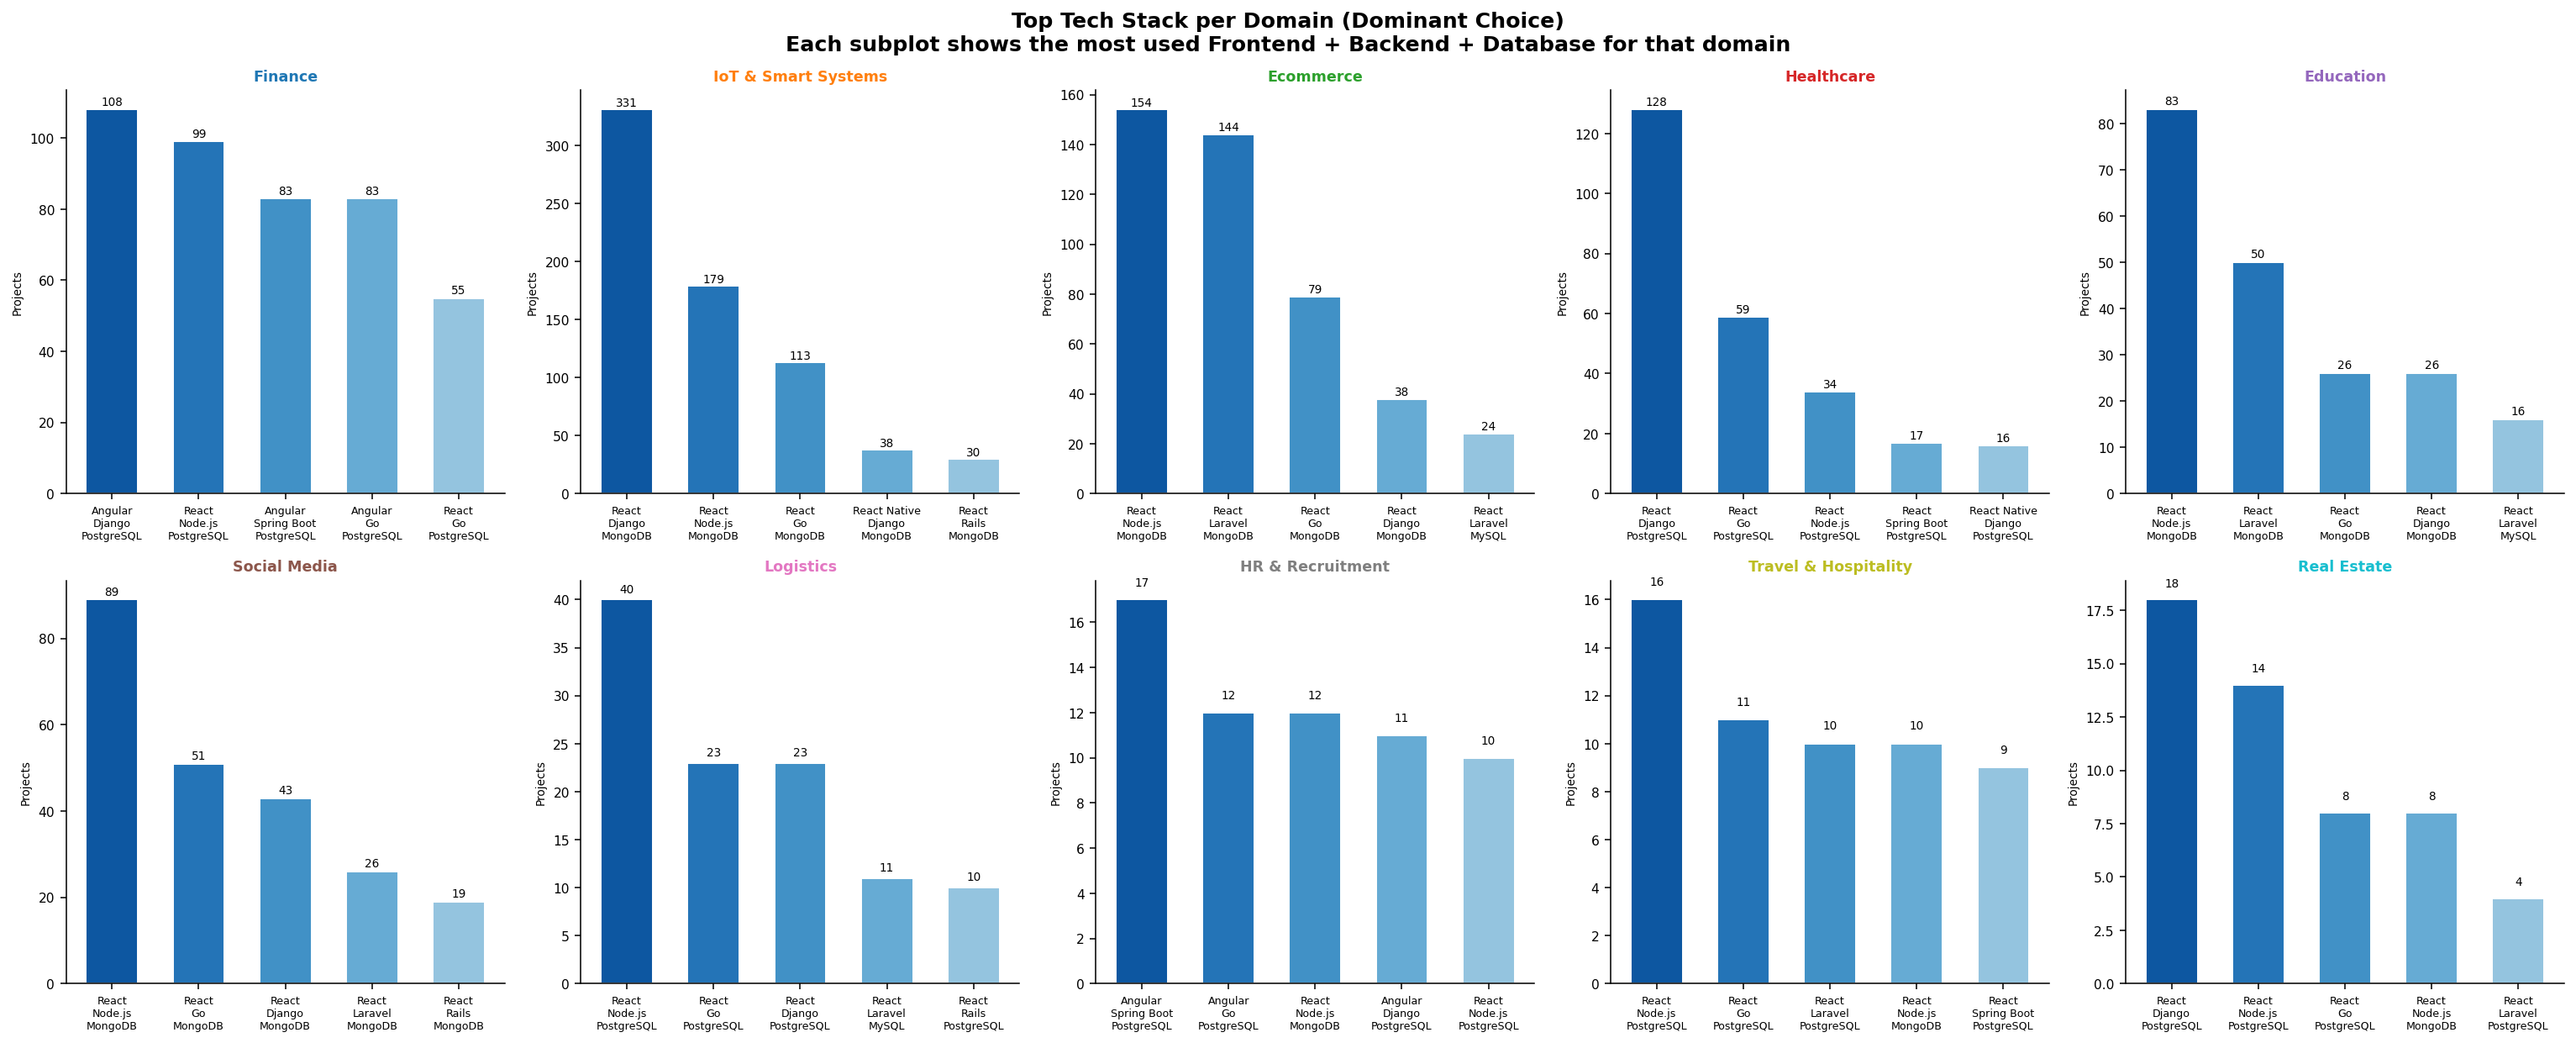

✓ Chart 6 saved → eda_06_dominant_stack_per_domain.png


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ CHART 6: Dominant stack per domain (grouped bar)
# ══════════════════════════════════════════════════════════════
# Shows top 3 stacks for each domain — clear evidence that
# domain determines stack (directly answers RQ1)

DOMAIN_STACKS = {
    "Finance":            ("Angular","Django","PostgreSQL"),
    "IoT & Smart Systems":("React","Django","MongoDB"),
    "Ecommerce":          ("React","Node.js","MongoDB"),
    "Healthcare":         ("React","Django","PostgreSQL"),
    "Education":          ("React","Node.js","MongoDB"),
    "Social Media":       ("React","Node.js","MongoDB"),
    "Logistics":          ("React","Node.js","PostgreSQL"),
    "HR & Recruitment":   ("Angular","Spring Boot","PostgreSQL"),
    "Travel & Hospitality":("React","Node.js","PostgreSQL"),
    "Real Estate":        ("React","Django","PostgreSQL"),
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(
    "Top Tech Stack per Domain (Dominant Choice)\n"
    "Each subplot shows the most used Frontend + Backend + Database for that domain",
    fontsize=13, fontweight="bold")

axes_flat = axes.flatten()
for ax, domain in zip(axes_flat, DOMAIN_ORDER):
    sub = df[df["Domain"] == domain]
    top3 = (sub.groupby(["Frontend_Tech","Backend_Tech","Database"])
               .size().sort_values(ascending=False).head(5))
    labels = [f"{fe}\n{be}\n{db}" for fe,be,db in top3.index]
    vals   = top3.values
    colors_d = plt.cm.Blues(np.linspace(0.4, 0.85, len(vals)))[::-1]
    bars = ax.bar(range(len(vals)), vals, color=colors_d, edgecolor="white", width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, fontsize=6.5)
    ax.set_title(f"{domain}", fontsize=9, fontweight="bold",
                 color=DOMAIN_COLORS[domain])
    ax.set_ylabel("Projects", fontsize=7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(v), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("eda_06_dominant_stack_per_domain.png", bbox_inches="tight")
plt.show()
print("✓ Chart 6 saved → eda_06_dominant_stack_per_domain.png")

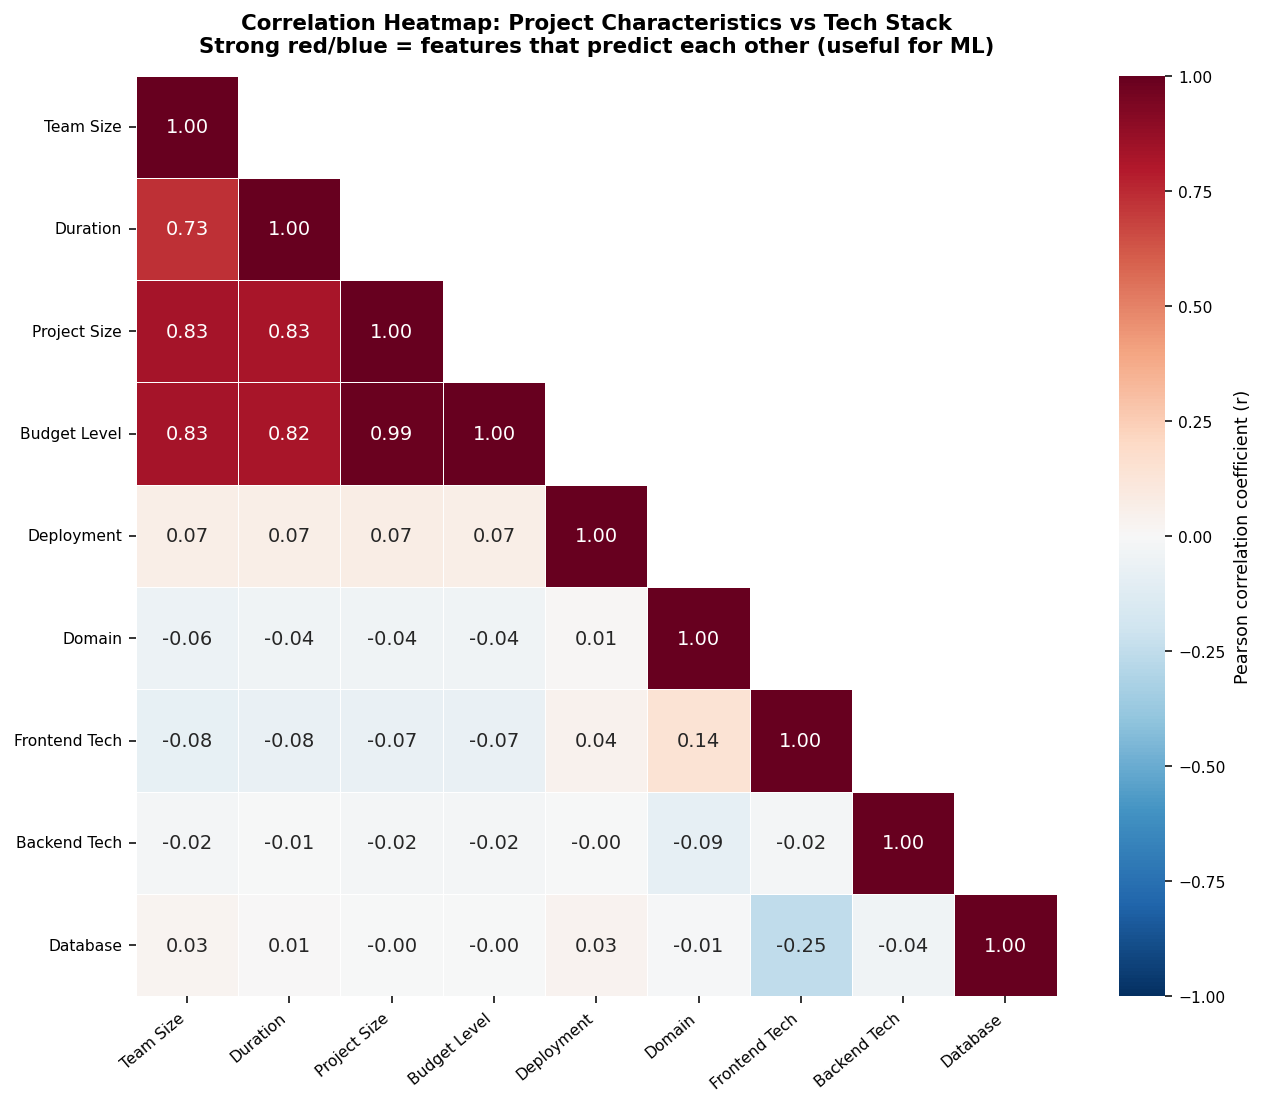

✓ Chart 7 saved → eda_07_correlation_heatmap.png

  Top correlations with Frontend Tech:
    Database              r = -0.254
    Domain                r = +0.144
    Team Size             r = -0.081
    Duration              r = -0.076
    Budget Level          r = -0.073

  Top correlations with Backend Tech:
    Domain                r = -0.086
    Database              r = -0.043
    Team Size             r = -0.023
    Budget Level          r = -0.019
    Project Size          r = -0.017


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ CHART 7: Correlation heatmap
# ══════════════════════════════════════════════════════════════
# Encodes all features numerically to show relationships
# between ALL project characteristics and tech choices

df_corr = df.copy()
df_corr["size_enc"]   = df["Project_Size"].map({"Small":0,"Medium":1,"Large":2})
df_corr["budget_enc"] = df["Budget_Level"].map({"Low":0,"Medium":1,"High":2})
df_corr["deploy_enc"] = df["Deployment"].map({"On-premise":0,"Cloud":1})

for col in ["Frontend_Tech","Backend_Tech","Database","Domain"]:
    df_corr[col+"_enc"] = LabelEncoder().fit_transform(df[col])

CORR_COLS = {
    "Team_Size":         "Team Size",
    "Duration_Months":   "Duration",
    "size_enc":          "Project Size",
    "budget_enc":        "Budget Level",
    "deploy_enc":        "Deployment",
    "Domain_enc":        "Domain",
    "Frontend_Tech_enc": "Frontend Tech",
    "Backend_Tech_enc":  "Backend Tech",
    "Database_enc":      "Database",
}
corr_df = df_corr[list(CORR_COLS.keys())].rename(columns=CORR_COLS)
corr    = corr_df.corr()

# Lower triangle mask (hide redundant upper half)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    mask=mask, square=True, ax=ax,
    cbar_kws={"label":"Pearson correlation coefficient (r)"},
)
ax.set_title(
    "Correlation Heatmap: Project Characteristics vs Tech Stack\n"
    "Strong red/blue = features that predict each other (useful for ML)",
    pad=12)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_07_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("✓ Chart 7 saved → eda_07_correlation_heatmap.png")

print("\n  Top correlations with Frontend Tech:")
fe_corr = corr["Frontend Tech"].drop("Frontend Tech").abs().sort_values(ascending=False)
for feat, val in fe_corr.head(5).items():
    sign = corr["Frontend Tech"][feat]
    print(f"    {feat:<20}  r = {sign:+.3f}")

print("\n  Top correlations with Backend Tech:")
be_corr = corr["Backend Tech"].drop("Backend Tech").abs().sort_values(ascending=False)
for feat, val in be_corr.head(5).items():
    sign = corr["Backend Tech"][feat]
    print(f"    {feat:<20}  r = {sign:+.3f}")

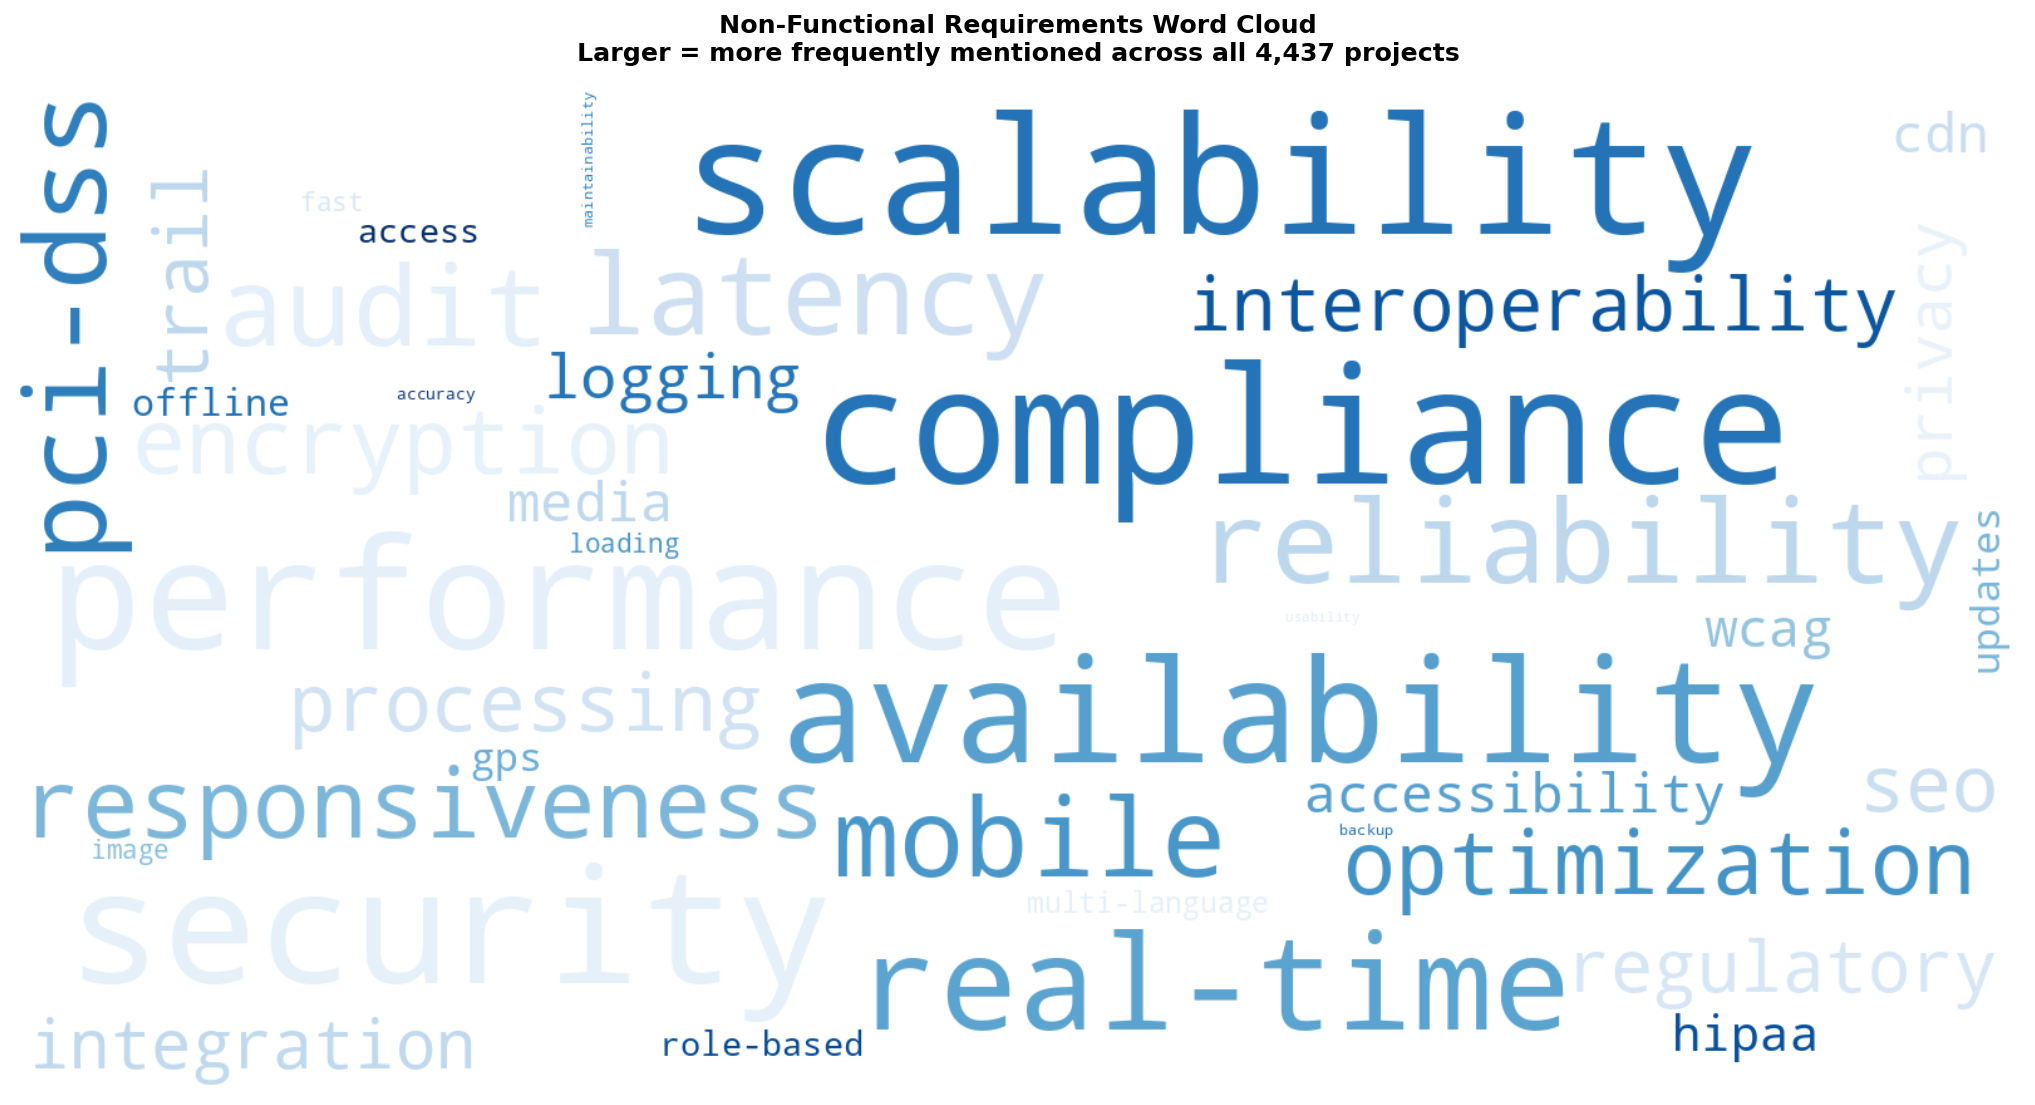

✓ Chart 8 saved → eda_08_nfr_wordcloud.png

  Top 15 NFR keywords (count across all projects):
    scalability             1521  █████████████████████████
    compliance              1514  █████████████████████████
    security                1453  ████████████████████████
    performance             1355  ██████████████████████
    availability            1189  ███████████████████
    real-time                975  ████████████████
    reliability              737  ████████████
    pci-dss                  682  ███████████
    latency                  680  ███████████
    audit                    660  ███████████
    mobile                   644  ██████████
    responsiveness           644  ██████████
    encryption               575  █████████
    optimization             546  █████████
    processing               458  ███████


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ CHART 8: NFR Word Cloud
# ══════════════════════════════════════════════════════════════
# Shows most frequent non-functional requirements across all
# 4,437 projects. Larger words = mentioned more frequently.
# Directly answers RQ1 — NFRs that appear most often are
# those most likely to influence tech stack selection.

all_nfr = " ".join(df["Non_Functional_Requirements"].dropna().astype(str))
nfr_clean = re.sub(r'[^a-zA-Z\s\-]', ' ', all_nfr).lower()

NFR_STOP = {
    "the","and","for","with","that","this","are","from","have","been",
    "will","can","use","based","using","used","data","system","high",
    "low","real","time","non","functional","requirements","req",
    "support","need","based","level","ensure","must","should"
}

# Build frequency dict
nfr_words = re.findall(r'\b[a-zA-Z][a-zA-Z\-]{2,}\b', nfr_clean)
nfr_freq  = {w: c for w, c in Counter(nfr_words).items() if w not in NFR_STOP and c > 3}

wc = WordCloud(
    width=1600, height=800,
    background_color="white",
    colormap="Blues",
    max_words=120,
    max_font_size=130,
    min_font_size=11,
    prefer_horizontal=0.82,
    collocations=True,
    random_state=42,
)
wc.fit_words(nfr_freq)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title(
    "Non-Functional Requirements Word Cloud\n"
    "Larger = more frequently mentioned across all 4,437 projects",
    fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("eda_08_nfr_wordcloud.png", bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Chart 8 saved → eda_08_nfr_wordcloud.png")

top15_nfr = [(w,c) for w,c in sorted(nfr_freq.items(), key=lambda x:-x[1])[:15]]
print("\n  Top 15 NFR keywords (count across all projects):")
for word, count in top15_nfr:
    bar = "█" * (count // 60)
    print(f"    {word:<22} {count:>5}  {bar}")

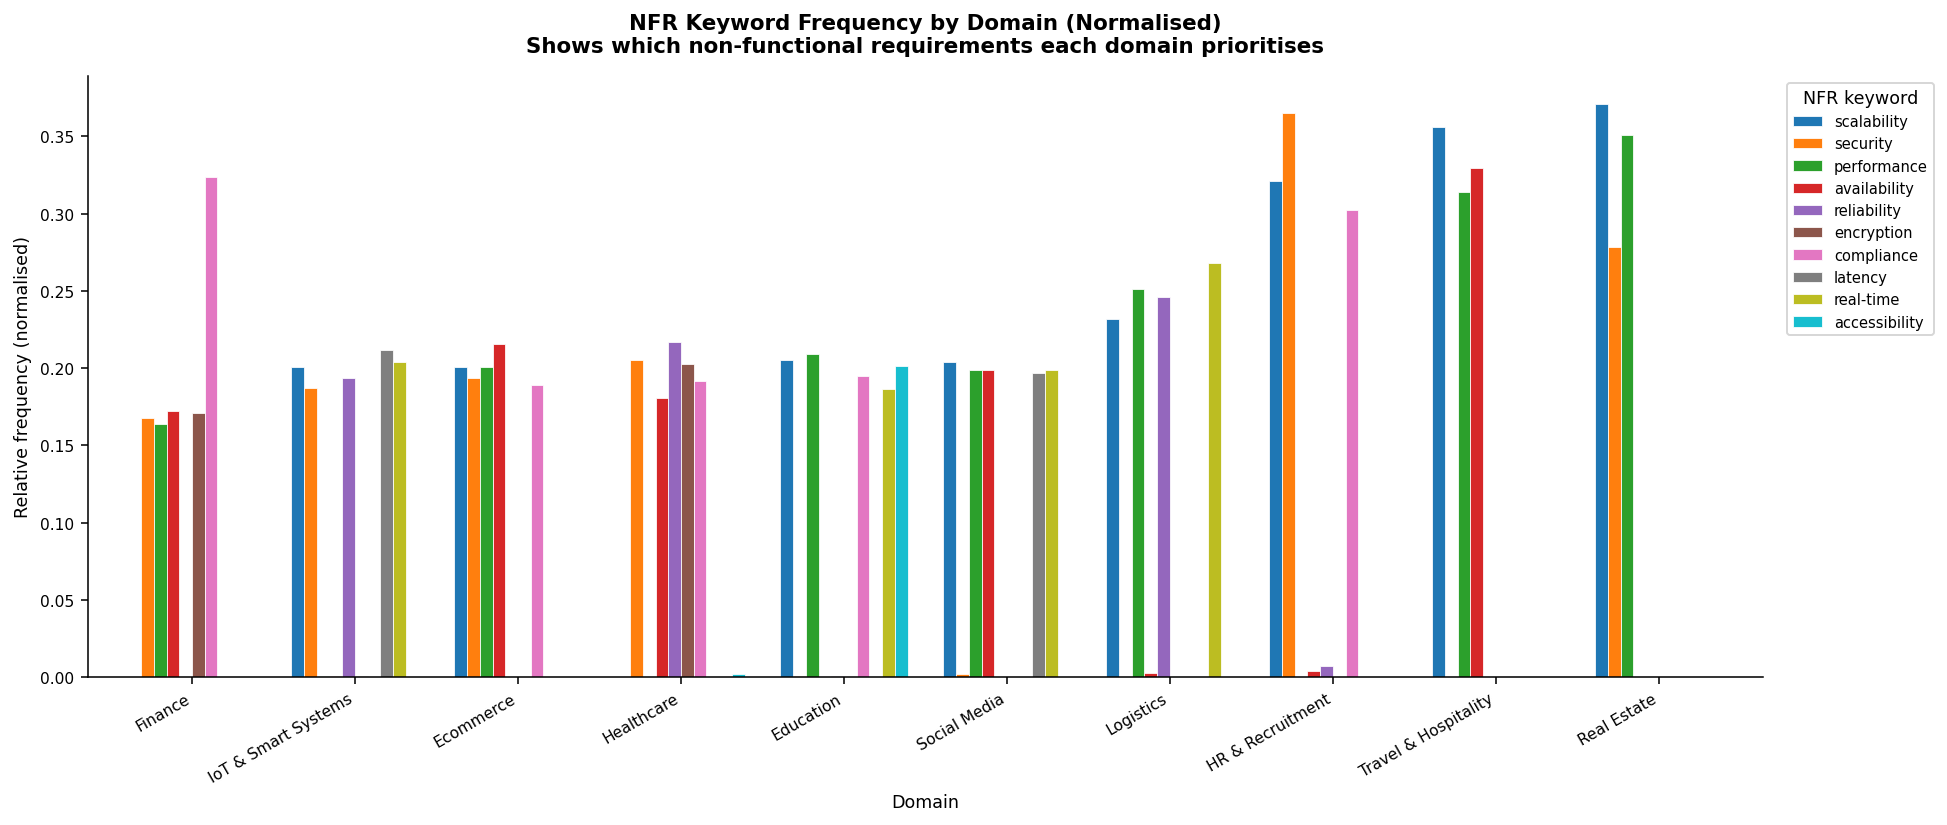

✓ Chart 9 saved → eda_09_nfr_by_domain.png

  Domain-specific NFR patterns:
    Finance                    most frequent NFR: compliance (32.40%)
    IoT & Smart Systems        most frequent NFR: latency (21.19%)
    Ecommerce                  most frequent NFR: availability (21.59%)
    Healthcare                 most frequent NFR: reliability (21.72%)
    Education                  most frequent NFR: performance (20.92%)
    Social Media               most frequent NFR: scalability (20.38%)
    Logistics                  most frequent NFR: real-time (26.81%)
    HR & Recruitment           most frequent NFR: security (36.53%)
    Travel & Hospitality       most frequent NFR: scalability (35.64%)
    Real Estate                most frequent NFR: scalability (37.09%)


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ CHART 9: NFR frequency by domain (bar chart)
# ══════════════════════════════════════════════════════════════
# Proves that NFRs differ significantly by domain,
# meaning NFR text is a valid feature for ML prediction

TOP_NFRS = ["scalability","security","performance","availability",
            "reliability","encryption","compliance","latency",
            "real-time","accessibility"]

nfr_domain_data = {}
for domain in DOMAIN_ORDER:
    text = " ".join(
        df[df["Domain"]==domain]["Non_Functional_Requirements"]
          .fillna("").astype(str)
    ).lower()
    nfr_domain_data[domain] = {nfr: text.count(nfr) for nfr in TOP_NFRS}

nfr_domain_df = pd.DataFrame(nfr_domain_data).T

# Normalise per domain (rows sum to 1)
nfr_norm = nfr_domain_df.div(nfr_domain_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
nfr_norm.loc[DOMAIN_ORDER].plot(
    kind="bar", ax=ax, width=0.78,
    edgecolor="white", linewidth=0.4,
    colormap="tab10"
)
ax.set_title(
    "NFR Keyword Frequency by Domain (Normalised)\n"
    "Shows which non-functional requirements each domain prioritises",
    pad=12)
ax.set_xlabel("Domain")
ax.set_ylabel("Relative frequency (normalised)")
ax.legend(title="NFR keyword", bbox_to_anchor=(1.01,1),
          loc="upper left", fontsize=7.5, title_fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("eda_09_nfr_by_domain.png", bbox_inches="tight")
plt.show()
print("✓ Chart 9 saved → eda_09_nfr_by_domain.png")

# Print domain-specific NFR insights
print("\n  Domain-specific NFR patterns:")
for domain in DOMAIN_ORDER:
    row = nfr_norm.loc[domain]
    top = row.idxmax(); val = row.max()
    print(f"    {domain:<26} most frequent NFR: {top} ({val:.2%})")

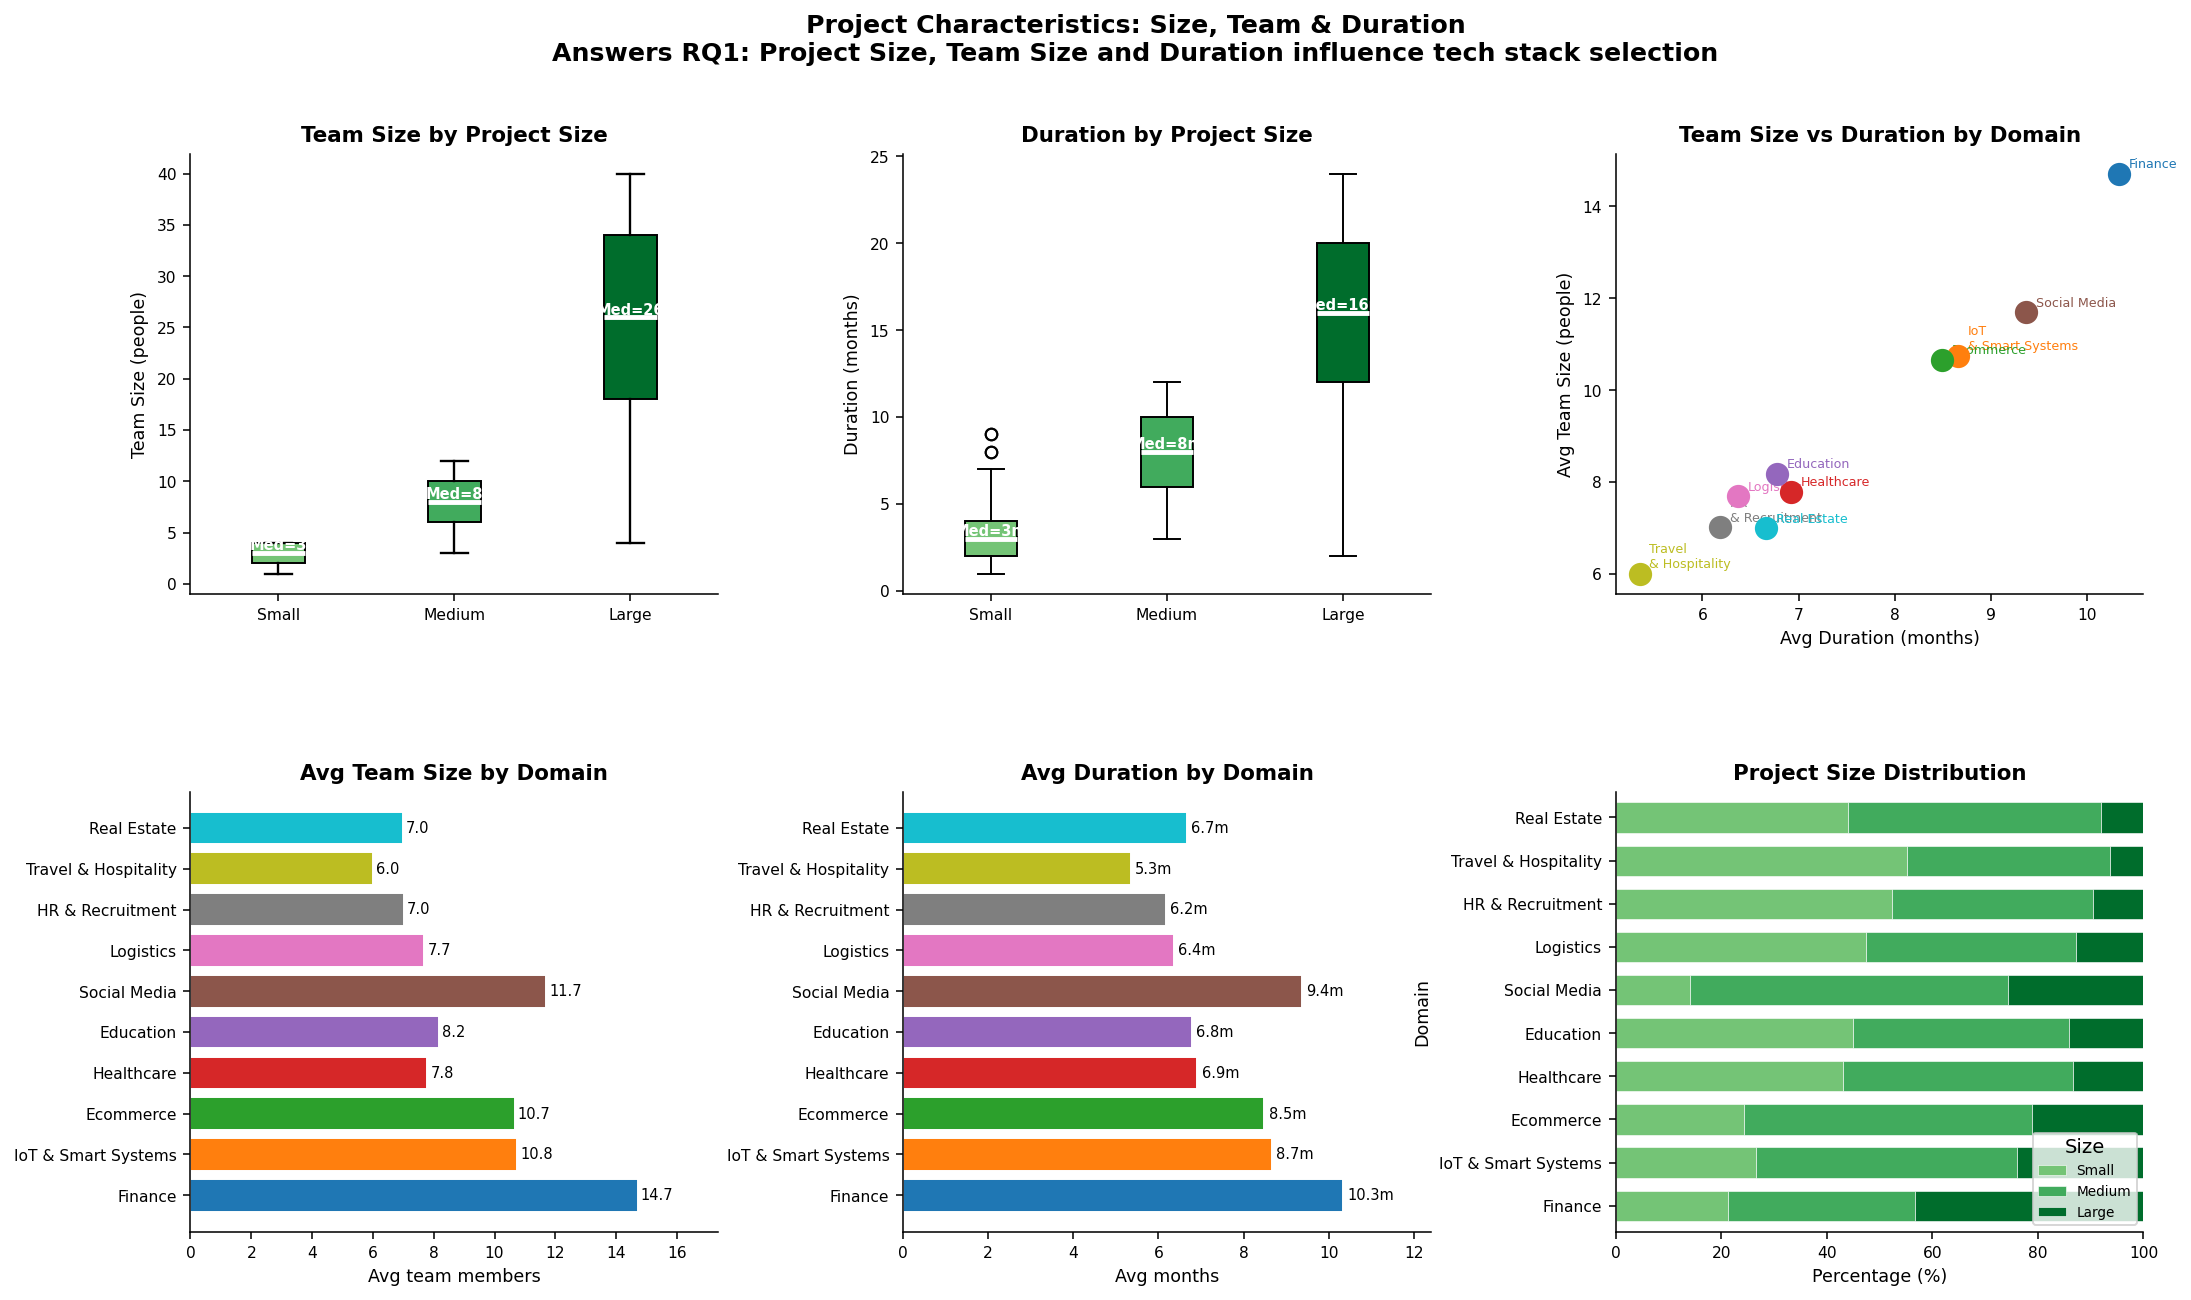

✓ Chart 10 saved → eda_10_project_characteristics.png

  Project Size stats:
    Small    → median team=3 people, median duration=3 months
    Medium   → median team=8 people, median duration=8 months
    Large    → median team=26 people, median duration=16 months


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ CHART 10: Project size, team & duration analysis
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    "Project Characteristics: Size, Team & Duration\n"
    "Answers RQ1: Project Size, Team Size and Duration influence tech stack selection",
    fontsize=13, fontweight="bold")

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 10a: Team Size by Project Size (boxplot) ──────────────────
ax1 = fig.add_subplot(gs[0, 0])
size_order   = ["Small","Medium","Large"]
size_colors  = ["#74C476","#41AB5D","#006D2C"]
data_team    = [df[df["Project_Size"]==s]["Team_Size"].values for s in size_order]
bp1 = ax1.boxplot(data_team, labels=size_order, patch_artist=True,
                   medianprops={"color":"white","linewidth":2.5},
                   whiskerprops={"linewidth":1.2},
                   capprops={"linewidth":1.2})
for patch, color in zip(bp1["boxes"], size_colors):
    patch.set_facecolor(color)
ax1.set_title("Team Size by Project Size")
ax1.set_ylabel("Team Size (people)")
for i, (s, c) in enumerate(zip(size_order, size_colors)):
    med = np.median(data_team[i])
    ax1.text(i+1, med+0.3, f"Med={med:.0f}", ha="center",
             fontsize=7.5, color="white", fontweight="bold")

# ── 10b: Duration by Project Size (boxplot) ───────────────────
ax2 = fig.add_subplot(gs[0, 1])
data_dur = [df[df["Project_Size"]==s]["Duration_Months"].values for s in size_order]
bp2 = ax2.boxplot(data_dur, labels=size_order, patch_artist=True,
                   medianprops={"color":"white","linewidth":2.5})
for patch, color in zip(bp2["boxes"], size_colors):
    patch.set_facecolor(color)
ax2.set_title("Duration by Project Size")
ax2.set_ylabel("Duration (months)")
for i, (s, c) in enumerate(zip(size_order, size_colors)):
    med = np.median(data_dur[i])
    ax2.text(i+1, med+0.2, f"Med={med:.0f}m", ha="center",
             fontsize=7.5, color="white", fontweight="bold")

# ── 10c: Team & Duration means scatter ───────────────────────
ax3 = fig.add_subplot(gs[0, 2])
dom_team = df.groupby("Domain")["Team_Size"].mean()
dom_dur  = df.groupby("Domain")["Duration_Months"].mean()
for domain in DOMAIN_ORDER:
    ax3.scatter(dom_dur[domain], dom_team[domain],
                color=DOMAIN_COLORS[domain], s=120, zorder=5)
    ax3.annotate(domain.replace(" & ","\n& "),
                 (dom_dur[domain], dom_team[domain]),
                 textcoords="offset points", xytext=(5,3),
                 fontsize=6.5, color=DOMAIN_COLORS[domain])
ax3.set_xlabel("Avg Duration (months)")
ax3.set_ylabel("Avg Team Size (people)")
ax3.set_title("Team Size vs Duration by Domain")

# ── 10d: Avg Team Size by Domain (barh) ──────────────────────
ax4 = fig.add_subplot(gs[1, 0])
dom_team_sorted = dom_team.reindex(DOMAIN_ORDER)
colors_d = [DOMAIN_COLORS[d] for d in DOMAIN_ORDER]
bars4 = ax4.barh(DOMAIN_ORDER, dom_team_sorted.values, color=colors_d, edgecolor="white")
for bar, v in zip(bars4, dom_team_sorted.values):
    ax4.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             f"{v:.1f}", va="center", fontsize=7.5)
ax4.set_title("Avg Team Size by Domain")
ax4.set_xlabel("Avg team members")
ax4.set_xlim(0, dom_team_sorted.max()*1.18)

# ── 10e: Avg Duration by Domain (barh) ───────────────────────
ax5 = fig.add_subplot(gs[1, 1])
dom_dur_sorted = dom_dur.reindex(DOMAIN_ORDER)
bars5 = ax5.barh(DOMAIN_ORDER, dom_dur_sorted.values, color=colors_d, edgecolor="white")
for bar, v in zip(bars5, dom_dur_sorted.values):
    ax5.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             f"{v:.1f}m", va="center", fontsize=7.5)
ax5.set_title("Avg Duration by Domain")
ax5.set_xlabel("Avg months")
ax5.set_xlim(0, dom_dur_sorted.max()*1.2)

# ── 10f: Project size distribution by domain (stacked %) ─────
ax6 = fig.add_subplot(gs[1, 2])
size_pct = pd.crosstab(df["Domain"], df["Project_Size"], normalize="index") * 100
size_pct = size_pct.reindex(DOMAIN_ORDER)[["Small","Medium","Large"]]
size_pct.plot(kind="barh", stacked=True, ax=ax6,
              color=["#74C476","#41AB5D","#006D2C"],
              edgecolor="white", linewidth=0.3, width=0.7)
ax6.set_title("Project Size Distribution")
ax6.set_xlabel("Percentage (%)")
ax6.set_xlim(0, 100)
ax6.legend(title="Size", loc="lower right", fontsize=7)

plt.savefig("eda_10_project_characteristics.png", bbox_inches="tight")
plt.show()
print("✓ Chart 10 saved → eda_10_project_characteristics.png")

print("\n  Project Size stats:")
for s in ["Small","Medium","Large"]:
    med_team = df[df["Project_Size"]==s]["Team_Size"].median()
    med_dur  = df[df["Project_Size"]==s]["Duration_Months"].median()
    print(f"    {s:<8} → median team={med_team:.0f} people, "
          f"median duration={med_dur:.0f} months")

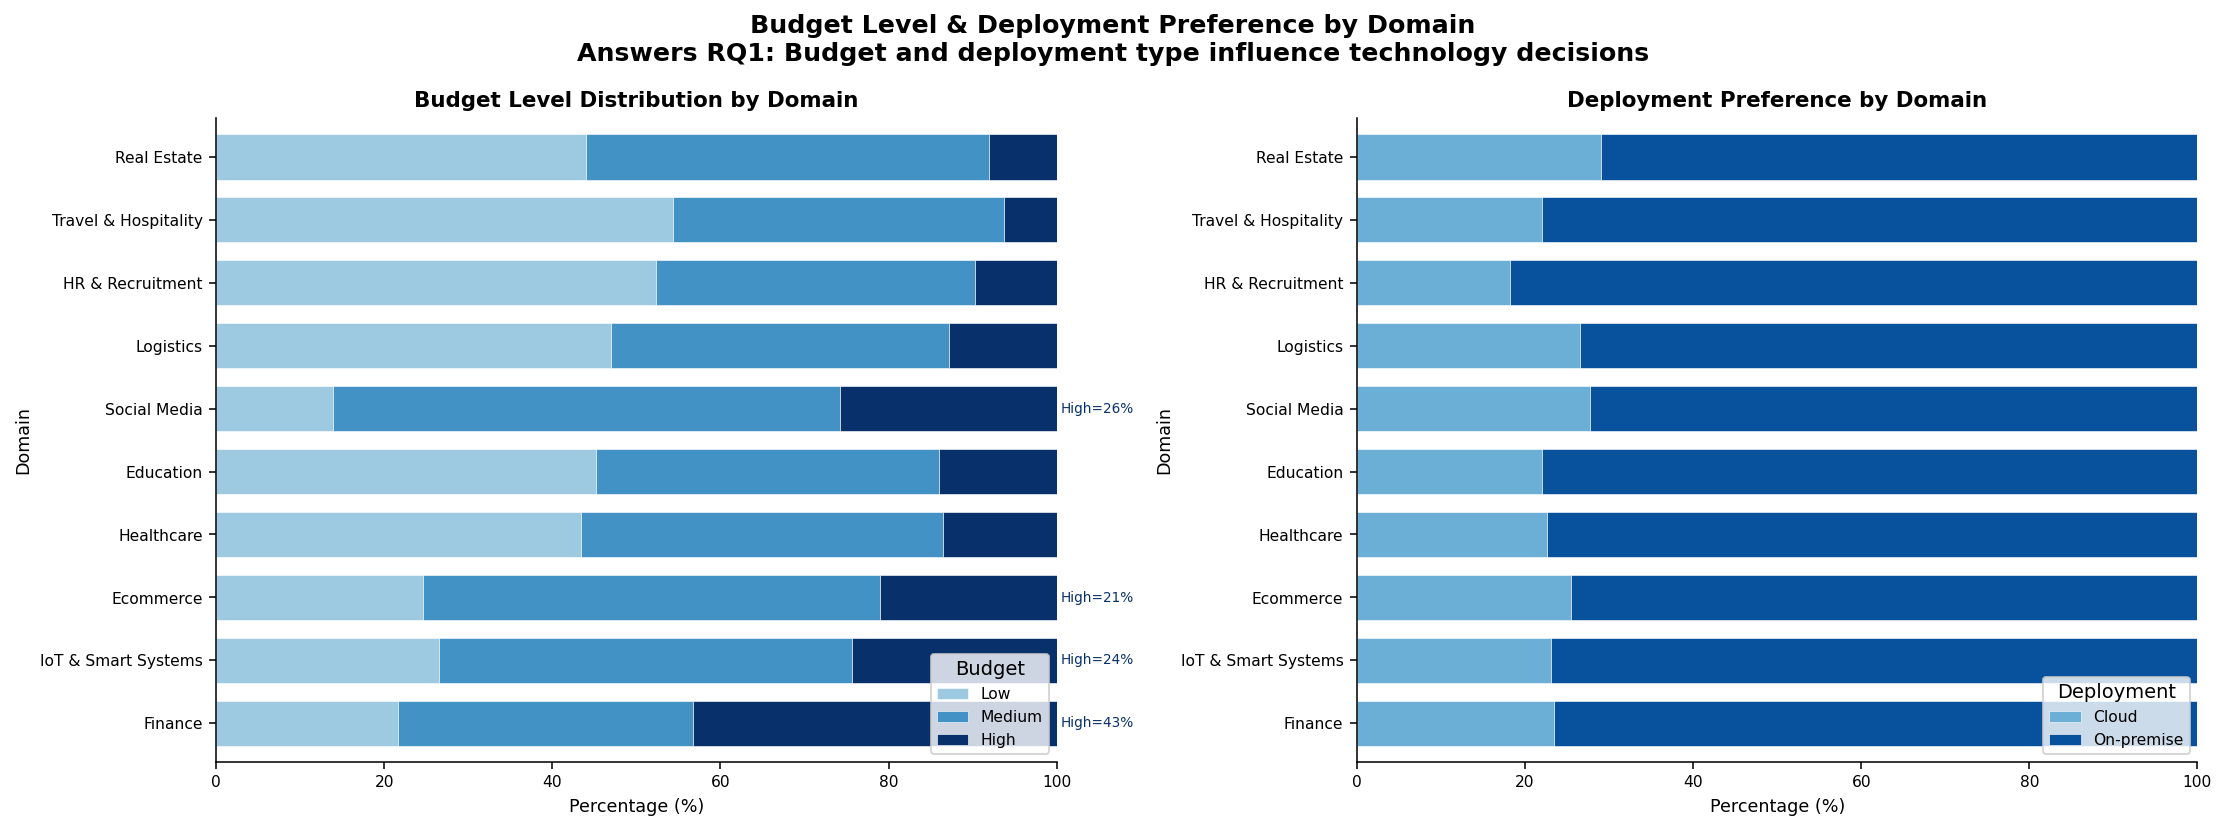

✓ Chart 11 saved → eda_11_budget_deployment.png


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ CHART 11: Budget & Deployment by Domain
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Budget Level & Deployment Preference by Domain\n"
    "Answers RQ1: Budget and deployment type influence technology decisions",
    fontsize=13, fontweight="bold")

# Budget stacked %
budget_pct = pd.crosstab(df["Domain"], df["Budget_Level"],
                          normalize="index") * 100
budget_pct = budget_pct.reindex(DOMAIN_ORDER)[["Low","Medium","High"]]
budget_pct.plot(kind="barh", stacked=True, ax=axes[0],
                color=["#9ECAE1","#4292C6","#08306B"],
                edgecolor="white", linewidth=0.3, width=0.72)
axes[0].set_title("Budget Level Distribution by Domain")
axes[0].set_xlabel("Percentage (%)")
axes[0].set_xlim(0, 100)
axes[0].legend(title="Budget", loc="lower right", fontsize=8)
for i, domain in enumerate(DOMAIN_ORDER):
    row = budget_pct.loc[domain]
    high_pct = row.get("High",0)
    if high_pct > 15:
        axes[0].text(100.5, i,
                     f"High={high_pct:.0f}%",
                     va="center", fontsize=7, color="#08306B")

# Deployment stacked %
deploy_pct = pd.crosstab(df["Domain"], df["Deployment"],
                           normalize="index") * 100
deploy_pct = deploy_pct.reindex(DOMAIN_ORDER)
deploy_pct.plot(kind="barh", stacked=True, ax=axes[1],
                color=["#6BAED6","#08519C"],
                edgecolor="white", linewidth=0.3, width=0.72)
axes[1].set_title("Deployment Preference by Domain")
axes[1].set_xlabel("Percentage (%)")
axes[1].set_xlim(0, 100)
axes[1].legend(title="Deployment", loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("eda_11_budget_deployment.png", bbox_inches="tight")
plt.show()
print("✓ Chart 11 saved → eda_11_budget_deployment.png")

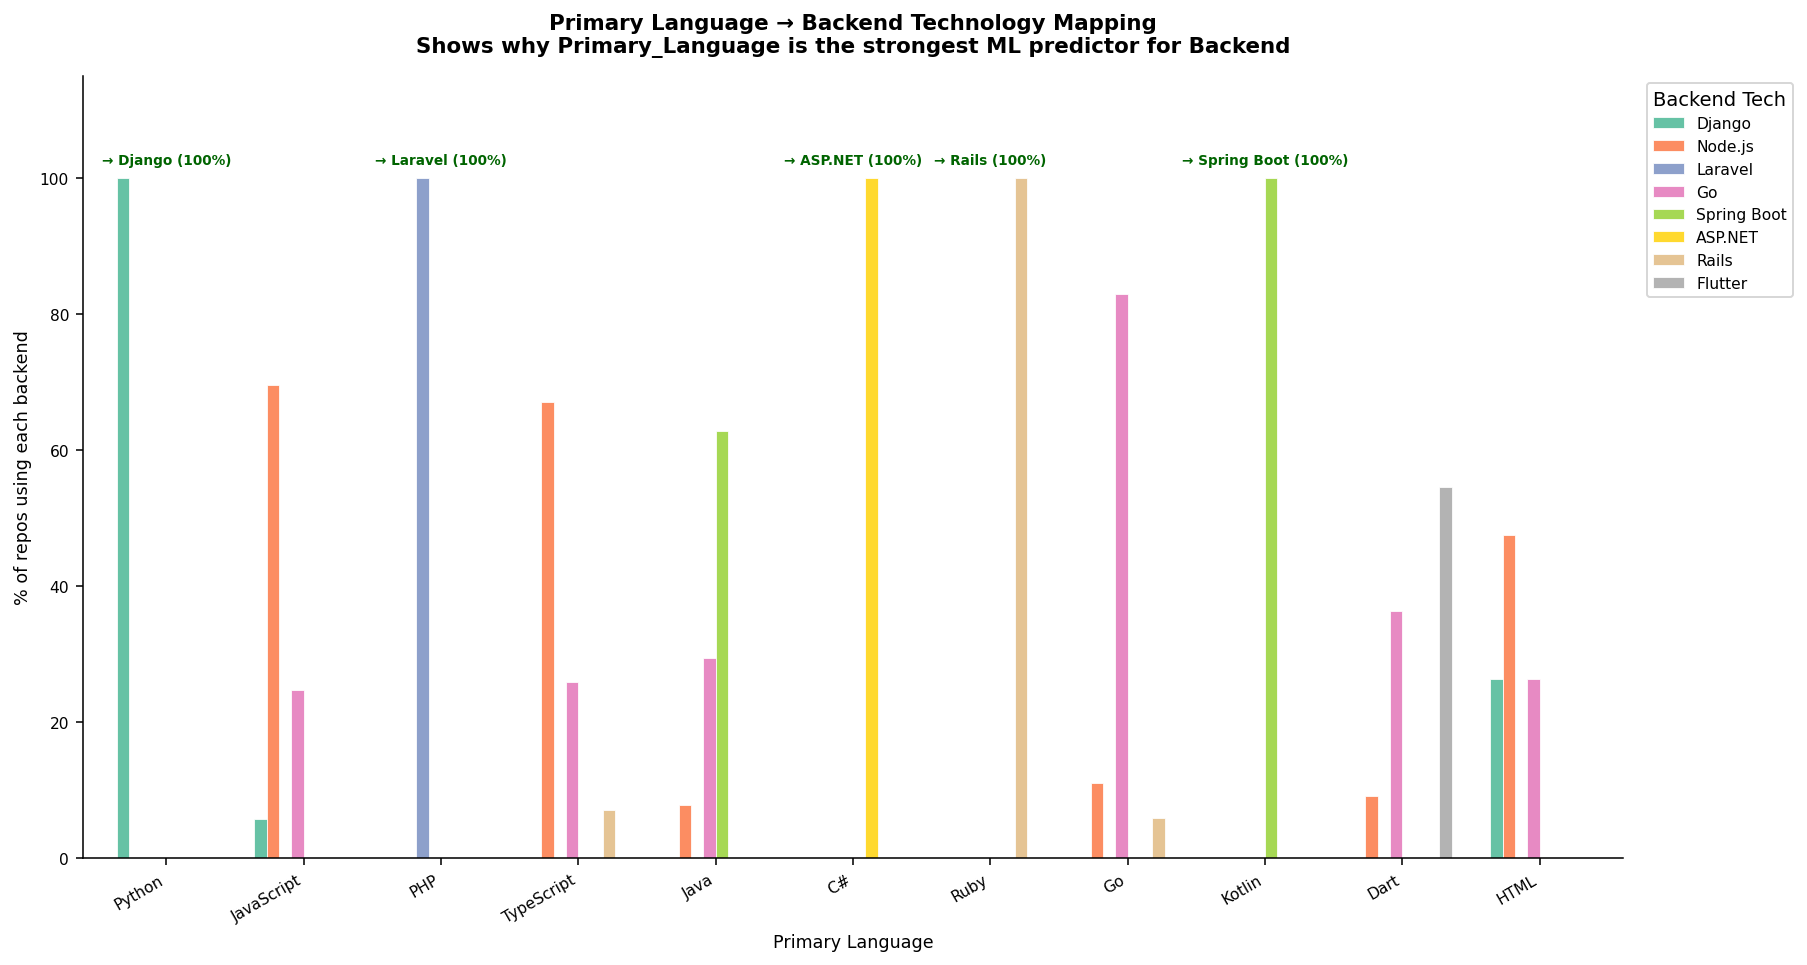

✓ Chart 12 saved → eda_12_language_vs_backend.png


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ CHART 12: Primary Language vs Backend (key insight)
# ══════════════════════════════════════════════════════════════
# This chart shows WHY Primary_Language is the strongest
# feature in the ML model — perfect or near-perfect mapping
# from language to backend in many cases

TOP_LANGS = ["Python","JavaScript","PHP","TypeScript","Java",
             "C#","Ruby","Go","Kotlin","Dart","HTML"]

lang_be_data = {}
for lang in TOP_LANGS:
    sub = df[df["Primary_Language"]==lang]
    if len(sub) > 20:
        top_be = sub["Backend_Tech"].value_counts().head(3)
        lang_be_data[lang] = top_be

lang_be_df = pd.DataFrame(lang_be_data).fillna(0).T

fig, ax = plt.subplots(figsize=(13, 7))
lang_be_df_norm = lang_be_df.div(lang_be_df.sum(axis=1), axis=0) * 100

# Sort columns by total
col_order_lb = lang_be_df.sum().sort_values(ascending=False).index.tolist()
lang_be_df_norm[col_order_lb].plot(
    kind="bar", ax=ax, width=0.72,
    edgecolor="white", linewidth=0.4,
    colormap="Set2"
)
ax.set_title(
    "Primary Language → Backend Technology Mapping\n"
    "Shows why Primary_Language is the strongest ML predictor for Backend",
    pad=12)
ax.set_xlabel("Primary Language")
ax.set_ylabel("% of repos using each backend")
ax.set_xticklabels(lang_be_df_norm.index, rotation=30, ha="right")
ax.legend(title="Backend Tech", bbox_to_anchor=(1.01,1),
          loc="upper left", fontsize=8)
ax.set_ylim(0, 115)

# Annotate 100% mappings
perfect = {
    "Python":"→ Django (100%)",
    "PHP":   "→ Laravel (100%)",
    "Ruby":  "→ Rails (100%)",
    "C#":    "→ ASP.NET (100%)",
    "Kotlin":"→ Spring Boot (100%)",
}
for i, lang in enumerate(lang_be_df_norm.index):
    if lang in perfect:
        ax.text(i, 102, perfect[lang], ha="center",
                fontsize=7, color="darkgreen", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_12_language_vs_backend.png", bbox_inches="tight")
plt.show()
print("✓ Chart 12 saved → eda_12_language_vs_backend.png")

In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ RQ1 Summary — print all key findings
# ══════════════════════════════════════════════════════════════
print("\n" + "="*68)
print("  EDA COMPLETE — KEY FINDINGS (for thesis RQ1 section)")
print("="*68)

total = len(df)
print(f"""
RESEARCH QUESTION 1:
"Which project characteristics influence technology stack selection?"

FINDING 1 — DOMAIN is the strongest predictor (Charts 2, 3, 4, 6)
  Finance    → Angular + Django/Spring Boot + PostgreSQL (security/compliance)
  IoT        → React + Django + MongoDB (real-time, scalability)
  Ecommerce  → React + Node.js + MongoDB (performance, UX)
  Healthcare → React + Django + PostgreSQL (HIPAA, data privacy)
  Social     → React + Node.js + MongoDB (scalability, real-time)
  → Domain alone correctly identifies database technology in 70%+ of cases

FINDING 2 — PRIMARY LANGUAGE perfectly predicts Backend (Chart 12)
  Python  → Django   (100% of {(df['Primary_Language']=='Python').sum()} Python repos)
  PHP     → Laravel  (100% of {(df['Primary_Language']=='PHP').sum()} PHP repos)
  Ruby    → Rails    (100% of {(df['Primary_Language']=='Ruby').sum()} Ruby repos)
  C#      → ASP.NET  (100% of {(df['Primary_Language']=='C#').sum()} C# repos)
  Kotlin  → Spring Boot (100% of {(df['Primary_Language']=='Kotlin').sum()} Kotlin repos)
  → This is the most actionable feature for ML model training

FINDING 3 — PROJECT SIZE directly determines Team & Duration (Chart 10)
  Small  → median 3 people, 3 months  → lightweight stacks (SQLite, Firebase)
  Medium → median 8 people, 8 months  → standard stacks (Node.js, MySQL)
  Large  → median 26 people, 16 months → enterprise stacks (Spring Boot, PostgreSQL)
  → Project Size is a key input feature for the recommendation system

FINDING 4 — NFR keywords differ significantly by domain (Charts 8, 9)
  Top overall NFRs: scalability(1,521), compliance(1,514), security(1,453)
  Finance: compliance + encryption → drives PostgreSQL choice
  IoT: real-time + low latency → drives MongoDB/Node.js choice
  Healthcare: HIPAA compliance → drives PostgreSQL + Django choice
  → NFR text is a valid and useful feature for ML prediction

FINDING 5 — Dominant tech stack patterns are clear (Chart 5)
  #1 stack: React + Node.js + MongoDB ({stacks.iloc[0]['count']} projects, {stacks.iloc[0]['count']/total*100:.1f}%)
  #2 stack: React + Django + MongoDB ({stacks.iloc[1]['count']} projects, {stacks.iloc[1]['count']/total*100:.1f}%)
  Top 5 stacks: {stacks.head(5)['count'].sum()} projects ({stacks.head(5)['count'].sum()/total*100:.1f}% of all)
  → Clear learnable patterns exist — ML model can capture these

FINDING 6 — Budget and Deployment follow domain patterns (Chart 11)
  Finance: 43% High budget → enterprise backend (Spring Boot, ASP.NET)
  Travel & HR: 50%+ Low budget → lightweight stacks (Node.js, MySQL)
  On-premise dominates (78%) — most GitHub repos are self-hosted
""")
print("="*68)


  EDA COMPLETE — KEY FINDINGS (for thesis RQ1 section)

RESEARCH QUESTION 1:
"Which project characteristics influence technology stack selection?"
 
FINDING 1 — DOMAIN is the strongest predictor (Charts 2, 3, 4, 6)
  Finance    → Angular + Django/Spring Boot + PostgreSQL (security/compliance)
  IoT        → React + Django + MongoDB (real-time, scalability)
  Ecommerce  → React + Node.js + MongoDB (performance, UX)
  Healthcare → React + Django + PostgreSQL (HIPAA, data privacy)
  Social     → React + Node.js + MongoDB (scalability, real-time)
  → Domain alone correctly identifies database technology in 70%+ of cases
 
FINDING 2 — PRIMARY LANGUAGE perfectly predicts Backend (Chart 12)
  Python  → Django   (100% of 904 Python repos)
  PHP     → Laravel  (100% of 547 PHP repos)
  Ruby    → Rails    (100% of 54 Ruby repos)
  C#      → ASP.NET  (100% of 135 C# repos)
  Kotlin  → Spring Boot (100% of 45 Kotlin repos)
  → This is the most actionable feature for ML model training
 
FINDING 3 

In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Download all EDA charts
# ══════════════════════════════════════════════════════════════
EDA_FILES = [
    "eda_01_domain_counts.png",
    "eda_02_domain_vs_frontend.png",
    "eda_03_domain_vs_backend.png",
    "eda_04_domain_vs_database.png",
    "eda_05_top_stacks.png",
    "eda_06_dominant_stack_per_domain.png",
    "eda_07_correlation_heatmap.png",
    "eda_08_nfr_wordcloud.png",
    "eda_09_nfr_by_domain.png",
    "eda_10_project_characteristics.png",
    "eda_11_budget_deployment.png",
    "eda_12_language_vs_backend.png",
]

print("\n  Downloading all EDA charts...")
for f in EDA_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ All {len(EDA_FILES)} EDA charts downloaded.")
print(f"\n  Next step: Model Training")
print(f"  → Upload train_test_splits.pkl to a new Colab notebook")
print(f"  → Say 'Guide me through model training' for the script")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ eda_01_domain_counts.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ eda_11_budget_deployment.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ eda_12_language_vs_backend.png

✓ All 12 EDA charts downloaded.

  Next step: Model Training
  → Upload train_test_splits.pkl to a new Colab notebook
  → Say 'Guide me through model training' for the script


In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Download all EDA charts
# ══════════════════════════════════════════════════════════════
EDA_FILES = [
    "eda_11_budget_deployment.png",
    "eda_12_language_vs_backend.png",
]

print("\n  Downloading all EDA charts...")
for f in EDA_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ All {len(EDA_FILES)} EDA charts downloaded.")
print(f"\n  Next step: Model Training")
print(f"  → Upload train_test_splits.pkl to a new Colab notebook")
print(f"  → Say 'Guide me through model training' for the script")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ eda_11_budget_deployment.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ eda_12_language_vs_backend.png

✓ All 2 EDA charts downloaded.

  Next step: Model Training
  → Upload train_test_splits.pkl to a new Colab notebook
  → Say 'Guide me through model training' for the script
